In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
df=pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
#影响存活的因素：
#性别（Sex）
#年龄（Age）
#船舱等级（Pclass）⭐
#票价（Fare）⭐
#上船港口（Embarked）
#是否有Cabin信息（Cabin）

In [4]:
df["Survived"].value_counts()
#死亡人数>存活人数

Survived
0    549
1    342
Name: count, dtype: int64

In [5]:
df["Survived"].mean()

np.float64(0.3838383838383838)

In [6]:
df.groupby("Sex")["Survived"].mean()
##不同性别生存下来的概率

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [7]:
#不同船舱等级生存下来的概率
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [8]:
#df.groupby("Age")["Survived"].mean()错错错

In [9]:
#Age分箱才有统计意义
df["AgeGroup"]=pd.cut(df["Age"],bins=[0,12,18,35,60,100])
df.groupby("AgeGroup")["Survived"].mean()#这个是和上面一样的，表示不同年龄段生存的概率

/tmp/ipykernel_16/3068926661.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()#这个是和上面一样的，表示不同年龄段生存的概率


AgeGroup
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

In [10]:
import numpy as np

In [11]:
import matplotlib.pyplot as plt
#groupby结果结构是index，values
#这里的age_survival为了后面的画图
age_survival=df.groupby("AgeGroup",observed=True)["Survived"].mean()
print(age_survival)

AgeGroup
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64


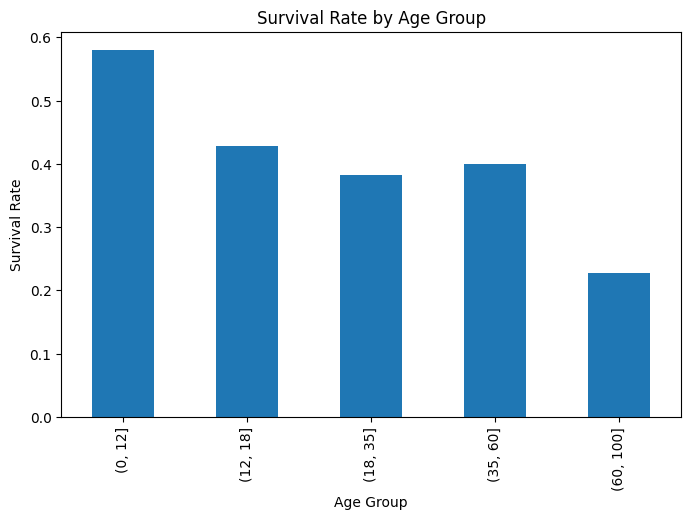

In [12]:
plt.figure(figsize=(8,5))
age_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

In [13]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

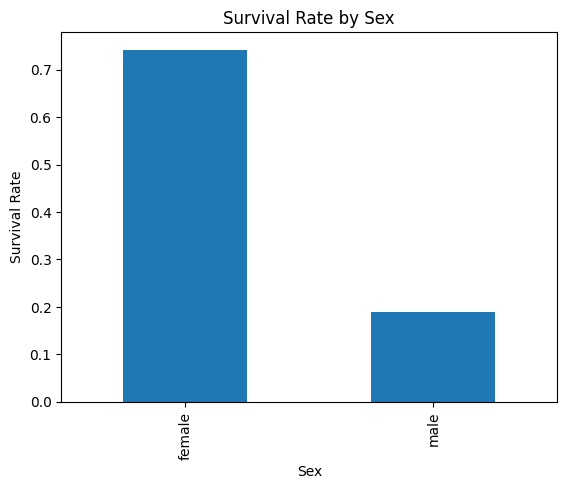

In [14]:
sex_survival=df.groupby("Sex")["Survived"].mean()
sex_survival.plot(kind="bar")
import matplotlib.pyplot as plt
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

In [15]:
df.groupby(["Sex","Pclass"])["Survived"].mean()#这叫做MultiIndex多层索引
#这个没有办法画图表需要重构数据结构

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [16]:
#unstack()让长表变成宽边排成Excel表
table=df.groupby(["Sex","Pclass"])["Survived"].mean().unstack()
table

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


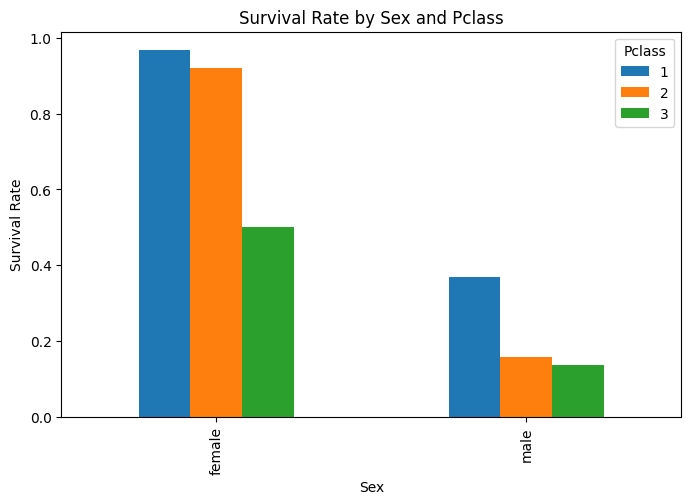

In [17]:
import matplotlib.pyplot as plt
table.plot(kind="bar", figsize=(8,5))
plt.title("Survival Rate by Sex and Pclass")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

In [18]:
#Numpy显示使用——————————————————————————————————

In [19]:
import numpy as np

In [20]:
#家庭大小
#FamilySize属于组装数据，自定义数据
df["FamilySize"]=df["SibSp"]+df["Parch"]+1  #df["SibSp"]是一列数据，这一步是向量化运算
df[["SibSp", "Parch", "FamilySize"]].head()


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [21]:
df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

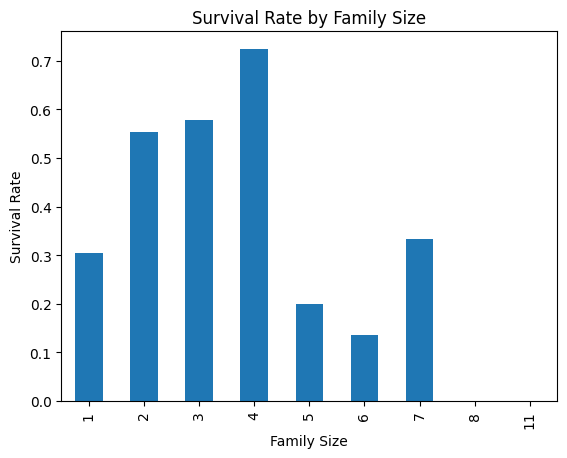

In [22]:
import matplotlib.pyplot as plt
df.groupby("FamilySize")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

In [23]:
#NumPy数组思维:专门处理数字数组的工具
#数值标准化
#用数值“改造特征”
import numpy as np


In [24]:
age=df["Age"].values#values将Series类型转换成numpy数组
#age#自行测试
age[:10]#0~9
np.nanmean(age)#处理缺失值：忽略NaN后再算平均值 nan+mean
#跳过空值再算平均
#只去掉NAN的
#age[~np.isnan(age)]numpy
#age_clean=df["Age"].dropna

np.float64(29.69911764705882)

In [25]:
#np.mean()不处理NaN
#np.nanmean()忽略NaN
#pd.Series.mean自动忽略
#mean是平均值/中心值

In [26]:
import numpy as np

In [27]:
#连续变量分析
#年龄分箱
df["AgeGroup"]=pd.cut(df["Age"],bins=[0,12,18,35,60,100])
age_survival=df.groupby("AgeGroup")["Survived"].mean()


/tmp/ipykernel_16/1181829705.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival=df.groupby("AgeGroup")["Survived"].mean()


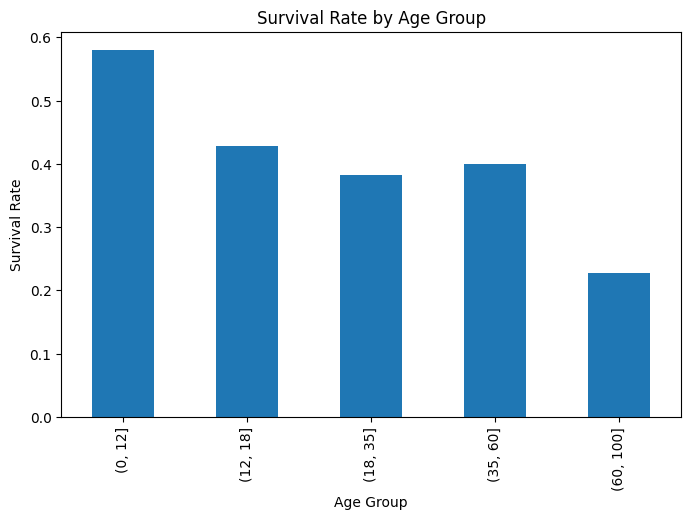

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
age_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

In [29]:
df["FareGroup"]=pd.qcut(df["Fare"],4)#qcut把票价分成四组，将每组人数控制的尽量一样（25%）
fare_survival=df.groupby("FareGroup")["Survived"].mean()
fare_survival

/tmp/ipykernel_16/454312436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival=df.groupby("FareGroup")["Survived"].mean()


FareGroup
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64

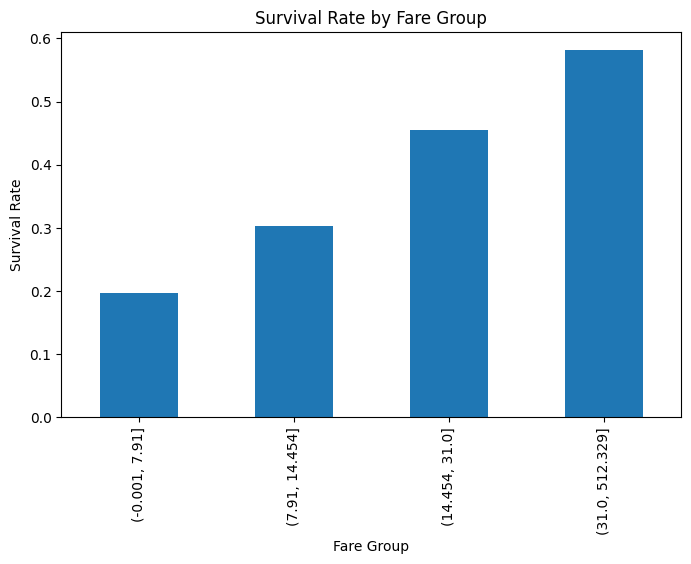

In [30]:
plt.figure(figsize=(8,5))

fare_survival.plot(kind="bar")

plt.title("Survival Rate by Fare Group")
plt.xlabel("Fare Group")
plt.ylabel("Survival Rate")

plt.show()

In [31]:
#组合元素后的生存率

In [32]:
#性别和船舱等级
df.groupby(["Sex", "Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

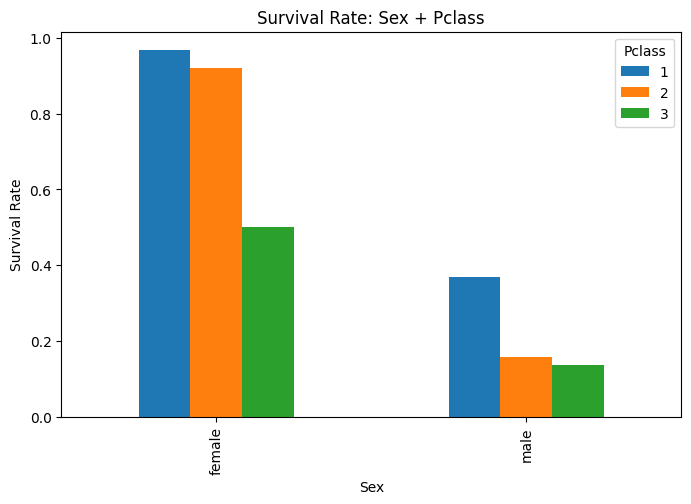

In [33]:
table = df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()

import matplotlib.pyplot as plt

table.plot(kind="bar", figsize=(8,5))

plt.title("Survival Rate: Sex + Pclass")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

In [34]:
#性别和年龄
df.groupby(["Sex", "AgeGroup"])["Survived"].mean()

/tmp/ipykernel_16/618449765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Sex", "AgeGroup"])["Survived"].mean()


Sex     AgeGroup 
female  (0, 12]      0.593750
        (12, 18]     0.750000
        (18, 35]     0.783333
        (35, 60]     0.771429
        (60, 100]    1.000000
male    (0, 12]      0.567568
        (12, 18]     0.088235
        (18, 35]     0.180672
        (35, 60]     0.192000
        (60, 100]    0.105263
Name: Survived, dtype: float64

/tmp/ipykernel_16/2989256989.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(["Sex", "AgeGroup"])["Survived"].mean().unstack()


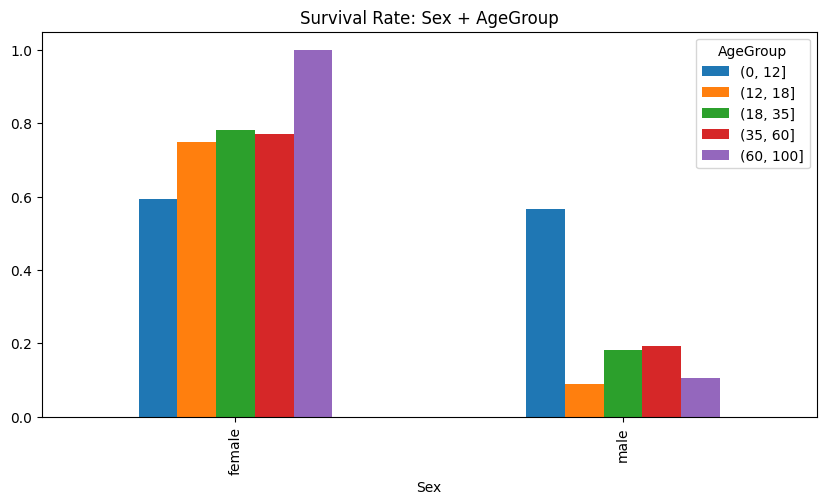

In [35]:
table = df.groupby(["Sex", "AgeGroup"])["Survived"].mean().unstack()

table.plot(kind="bar", figsize=(10,5))

plt.title("Survival Rate: Sex + AgeGroup")
plt.show()

In [36]:
#船舱等级和票价
df.groupby(["Pclass", "FareGroup"])["Survived"].mean()

/tmp/ipykernel_16/2356771947.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Pclass", "FareGroup"])["Survived"].mean()


Pclass  FareGroup      
1       (-0.001, 7.91]     0.000000
        (7.91, 14.454]          NaN
        (14.454, 31.0]     0.529412
        (31.0, 512.329]    0.685535
2       (-0.001, 7.91]     0.000000
        (7.91, 14.454]     0.383721
        (14.454, 31.0]     0.600000
        (31.0, 512.329]    0.545455
3       (-0.001, 7.91]     0.208531
        (7.91, 14.454]     0.253623
        (14.454, 31.0]     0.316832
        (31.0, 512.329]    0.195122
Name: Survived, dtype: float64

/tmp/ipykernel_16/2972155177.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table2=df.groupby(["Pclass", "FareGroup"])["Survived"].mean().unstack()


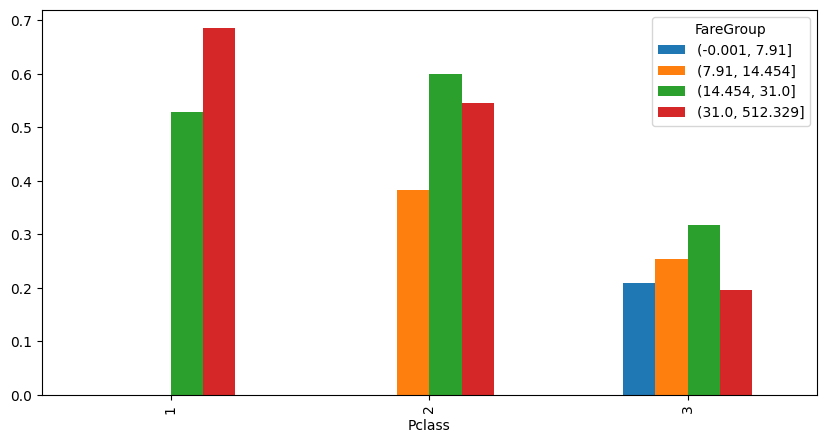

In [37]:
table2=df.groupby(["Pclass", "FareGroup"])["Survived"].mean().unstack()
table2.plot(kind="bar", figsize=(10,5))
plt.show()

In [38]:
#第一个机器学习模型

In [39]:
#输入（特征）Sex/Age/Pclass/Fare
#输出（标签）Survived（0/1）


In [40]:
#机器学习专用数据集
import pandas as pd
df_ml=df[["Survived","Sex","Age","Pclass","Fare","SibSp","Parch"]].copy()
df_ml.head()

,Survived,Sex,Age,Pclass,Fare,SibSp,Parch
0,0,male,22.0,3,7.2500,1,0
1,1,female,38.0,1,71.2833,1,0
2,1,female,26.0,3,7.9250,0,0
3,1,female,35.0,1,53.1000,1,0
4,0,male,35.0,3,8.0500,0,0


In [41]:
#在建立机器学习模型之前，通常需要进行：

#把非数字特征转换成数字（例如 Sex）
#处理缺失值 NaN
#特征选择、特征缩放等

#因为机器学习模型最终需要输入一个纯数字矩阵。

In [42]:
df_ml["Sex"]=df_ml["Sex"].map({"male":0,"female":1})
#map=把原来的值，按规则替换成新值，编码转换
#大多数机器学习模型只能接受数值形式的输入，不能直接处理字符串类别

In [43]:
#fillna填补缺失值，这里是用平均年龄填补空值，sklearn不接受NaN
df_ml["Age"]=df_ml["Age"].fillna(df_ml["Age"].mean())#.fillna(29.7)用平均值替换掉NaN
df_ml["Fare"] = df_ml["Fare"].fillna(df_ml["Fare"].mean())

In [44]:
X=df_ml[["Sex","Age","Pclass","Fare"]]#特征值
y=df_ml["Survived"]

In [45]:
#拆分训练集和测试集
from sklearn.model_selection import train_test_split  #导入函数
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

#sklearn机器学习库
#model.selectoin模型选择模块（数据划分，交叉验证，参数选择）
#train_test_split训练用例和测试用例的划分

#test_size测试集比例20%做测试
#random_state随机种子，保证每次结果一样

#X_train → 给模型学习的数据
#y_train → 学习时的答案
#X_test → 给模型考试的数据
#y_test → 考试标准答案

In [46]:
#输入要求（X）

#2D（表格）
#全是数字
#没有 NaN
#dtype = int / float



#输出要求（y）

#1D（Series）
#0/1 或分类标签
#没 NaN


In [47]:
#只接受纯数字矩阵DataFrame/numpy array
#从 sklearn（机器学习库）里面：导入LogisticRegression，逻辑回归模型
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()#f(x)=sigmoid(wx+b)
model.fit(X_train,y_train)#更新w,b;训练完成

LogisticRegression()

In [48]:
#fit后，要用模型进行预测
y_pred=model.predict(X_test)

In [49]:
#计算准确率

In [50]:
#导入评价函数
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.2f}")

Accuracy:0.80


In [51]:
#查看模型学习出来的参数 w 和 b，理解模型到底学到了什么规律。
print(model.coef_)
print(model.intercept_)
print(X.columns)

[[ 2.46478078e+00 -2.55666489e-02 -9.96389927e-01  1.15843260e-03]]
[1.52259159]
Index(['Sex', 'Age', 'Pclass', 'Fare'], dtype='object')


In [52]:
#死亡概率  生存概率
#查看模型对于每一个测试样本属于每个类别的概率，而不是直接查看0/1预测结果
y_prob = model.predict_proba(X_test)
print(y_prob)

[[0.90098559 0.09901441]
 [0.77740212 0.22259788]
 [0.8774747  0.1225253 ]
 [0.1324554  0.8675446 ]
 [0.34224802 0.65775198]
 [0.08184102 0.91815898]
 [0.43834696 0.56165304]
 [0.86468885 0.13531115]
 [0.35477529 0.64522471]
 [0.07339554 0.92660446]
 [0.58861712 0.41138288]
 [0.92970622 0.07029378]
 [0.43330064 0.56669936]
 [0.90249047 0.09750953]
 [0.79827182 0.20172818]
 [0.06738574 0.93261426]
 [0.61933276 0.38066724]
 [0.43832438 0.56167562]
 [0.75867486 0.24132514]
 [0.64912433 0.35087567]
 [0.8880555  0.1119445 ]
 [0.57744852 0.42255148]
 [0.37249341 0.62750659]
 [0.8773127  0.1226873 ]
 [0.90106264 0.09893736]
 [0.84421422 0.15578578]
 [0.61404599 0.38595401]
 [0.77690056 0.22309944]
 [0.82295892 0.17704108]
 [0.44652158 0.55347842]
 [0.87470303 0.12529697]
 [0.39061825 0.60938175]
 [0.54922658 0.45077342]
 [0.43840401 0.56159599]
 [0.87185408 0.12814592]
 [0.89474318 0.10525682]
 [0.53706691 0.46293309]
 [0.43834696 0.56165304]
 [0.09449941 0.90550059]
 [0.90174258 0.09825742]


In [53]:
#提高模型效果
#不是看到80%就马上改代码，而是先分析模型为什么只有80%，哪里错了，然后针对性改进
#第一个baseline模型（上面的那个80%的就是）
#        ↓
#     分析错误
#        ↓
#     改进特征
#        ↓
#     重新训练
#        ↓
#    比较准确率

In [54]:
#混淆矩阵
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)
#|          | 预测死亡0| 预测生存1 |
#| -----    | -----  | ----- |
#| 真实死亡0 | 89     | 16    |
#| 真实生存1 | 20     | 54    |

[[89 16]
 [20 54]]


In [55]:
X.columns

Index(['Sex', 'Age', 'Pclass', 'Fare'], dtype='object')

In [56]:
#创造更好的特征-----特征工程

In [57]:
df_ml["FamilySize"]=df_ml["SibSp"]+df_ml["Parch"]+1
family_survival=df_ml.groupby("FamilySize")["Survived"].mean()
print(family_survival)

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [58]:
df_ml["Sex"] = df_ml["Sex"].map({
    "male":0,
    "female":1
})

In [59]:
df_ml["Age"]=df_ml["Age"].fillna(df_ml["Age"].mean())#.fillna(29.7)用平均值替换掉NaN
df_ml["Fare"] = df_ml["Fare"].fillna(df_ml["Fare"].mean())

In [60]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "FamilySize"
]

In [61]:
X = df_ml[features]
y = df_ml["Survived"]

In [62]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

In [ ]:
#下一步优化的：IsAlone（是否独自旅行）